# CourtSight - Dataset Exploration

This notebook explores the OpenNyaya Supreme Court Judgments dataset and evaluates its suitability for metadata extraction, semantic search, clustering, anomaly detection, and legal intelligence applications.

DataSet - "OpenNyaya Indian Supreme Court Judgement Clean"

In [2]:
from pathlib import Path

data_path = Path("../data/raw/archive (1)/nyai-supreme-court-clean")

files = list(data_path.rglob("*.md"))

print("Total Files:", len(files))

Total Files: 33016


In [3]:
with open(files[0], encoding="utf-8") as f:
    text = f.read()

print(text[:3000])

Patntalal Jankid-:u

v, Mohanlal and

Another,

Pata1tjali S11stri J.

!950

Deo, 21.

SUPREME COURT REPORTS [1950]

of section 14, it seems to me, they would be bringing themselves under the bar of section 18 (2).

The respondents cannot therefore claim that the loss of the goods was explosion damage within the meaning of the Ordinance so as to bring the case within section 14 and at the same time contend that the loss was not "due to or did not in any way arise ont of the explosion" in order to a void the bar under section 18.

Both section 14 and section 18 have in view the physical cause for the loss or damage to property for which compensation is claimed and not the cause of action in relation to the person against whom relief is sought. The respondents cannot, in my opinion, be allowed to take up inconsistent positions in order to bring themselves within the one and to get out of the other.

I would therefore allow the appeal and dismiss the counter-claim.

DAS J. agreed with the

## Checking Formatting and Consistency of Information Throughout the DataSet

In [4]:
import random

samples = random.sample(files, 10)

for file in samples:
    print("=" * 100)
    print(file.name)

    with open(file, encoding="utf-8") as f:
        text = f.read()

    print(text[:1500])

S_2004_5_344_350_EN.md
P. JANARDHANA RAO.

KANNAN AND ORS.

OCTOBER 12, 2004

[ASHOK BHAN AND S.H. KAPADIA, JJ.]

Civil Procedure Code, 1908; Order 21 Rule 97:

Suit for ejectment-Decreed by Court of Small Causes-Delivery of C possession resisted-:-petition for removal of obstruction-Allowed by execution Court on ground that no evidence of possession furnished by obstructionists- Reversed by High Court-On appeal, . Held: Obstructionists failed to produce any evidence to show that they were in possession of suit property prior to filing of ejectment suit-Apparently evidence has been created since filing of D the suit-Merely because a prosecution witness stated, it would not be sufficient to conclude that obstructionists resided in the suit property for the alleged period-High Court has failed to appreciate entire evidence on record-Trial Court rightly decreed the suit-Order of the High Court set aside and that of the executing Court restored

E An ejectment suit filed by the appellant w

Judgment headers appear highly structured.

Potential fields:

Case Name
Date
Judges
Acts
Legal Domain

Judgments span multiple legal areas:

Criminal Law
Constitutional Law
Tax Law
Labour Law
Arbitration
Property Law

Text appears sufficiently clean for embedding generation. Metadata extraction is likely feasible using regex and rule-based parsing before introducing ML.

## Next Steps

- Explore document length distributions
- Extract metadata fields (case name, judges, date)
- Evaluate extraction success rate
- Generate legal case embeddings
- Build semantic search prototype

In [5]:
lengths = []

for file in files[:1000]:
    with open(file, encoding="utf-8") as f:
        text = f.read()

    lengths.append(len(text))


In [6]:
import pandas as pd

pd.Series(lengths).describe()

count      1000.000000
mean      35353.371000
std       43783.314461
min        4546.000000
25%       18293.250000
50%       25791.500000
75%       38171.000000
max      807789.000000
dtype: float64

In [7]:
for file in files:
    first_part = file.stem.split("_")[0]

    if not first_part.isdigit():
        print(file.name)
        break

S_1959_1_979_1008_EN.md


In [8]:
weird = []

for file in files:
    first = file.stem.split("_")[0]

    if not first.isdigit():
        weird.append(file.name)

len(weird)

7383

In [9]:
weird[:20]

['S_1959_1_979_1008_EN.md',
 'S_1959_2_1002_1011_EN.md',
 'S_1959_2_1012_1046_EN.md',
 'S_1959_2_107_122_EN.md',
 'S_1959_2_123_136_EN.md',
 'S_1959_2_136_149_EN.md',
 'S_1959_2_150_180_EN.md',
 'S_1959_2_180_201_EN.md',
 'S_1959_2_1_7_EN.md',
 'S_1959_2_201_212_EN.md',
 'S_1959_2_213_216_EN.md',
 'S_1959_2_217_227_EN.md',
 'S_1959_2_227_255_EN.md',
 'S_1959_2_256_269_EN.md',
 'S_1959_2_270_300_EN.md',
 'S_1959_2_301_315_EN.md',
 'S_1959_2_316_338_EN.md',
 'S_1959_2_339_354_EN.md',
 'S_1959_2_355_364_EN.md',
 'S_1959_2_364_375_EN.md']

In [10]:
years = []

for file in files:
    parts = file.stem.split("_")

    if parts[0].isdigit():
        years.append(int(parts[0]))
    else:
        years.append(int(parts[1]))

pd.Series(years).value_counts().sort_index()

1950      41
1951      39
1952      44
1953      48
1954      33
        ... 
2022    1017
2023     853
2024     782
2025     758
2026      18
Name: count, Length: 76, dtype: int64

In [11]:
import re

def extract_case_name(text):
    lines = text.split("\n")

    for line in lines[:50]:
        if " v. " in line.lower():
            return line.strip()

    return None

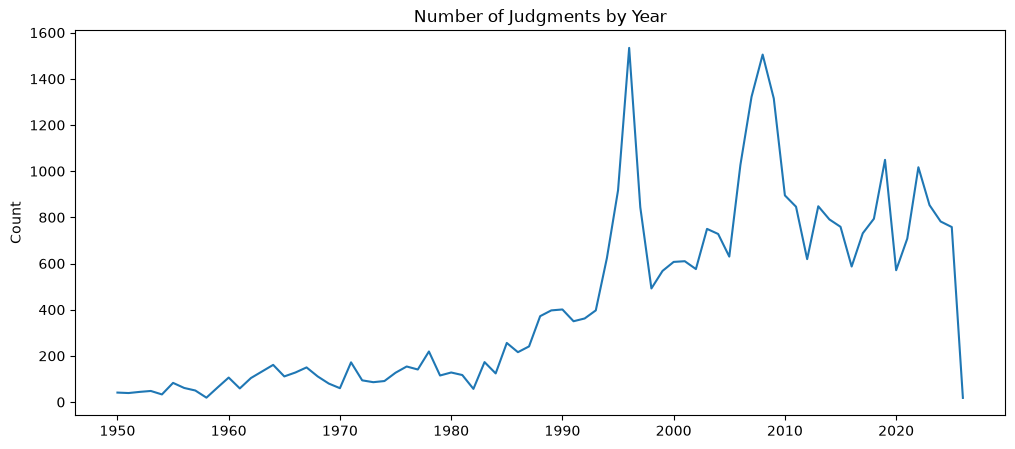

In [30]:
import matplotlib.pyplot as plt
year_counts = pd.Series(years).value_counts().sort_index()

year_counts.plot(
    figsize=(12,5),
    title="Number of Judgments by Year"
)

plt.ylabel("Count")

plt.savefig(
    "../figures/Judgements_per_Year.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
year_counts.sort_values(ascending=False).head(10)

1996    1534
2008    1505
2007    1322
2009    1315
2019    1049
2006    1027
2022    1017
1995     917
2010     895
2023     853
Name: count, dtype: int64

In [16]:
lengths = []

for file in files[:2000]:
    with open(file, encoding="utf-8") as f:
        lengths.append(len(f.read()))

In [17]:
pd.Series(lengths).describe()

count    2.000000e+03
mean     3.240883e+04
std      7.273780e+04
min      3.506000e+03
25%      1.682550e+04
50%      2.335350e+04
75%      3.476675e+04
max      2.862997e+06
dtype: float64

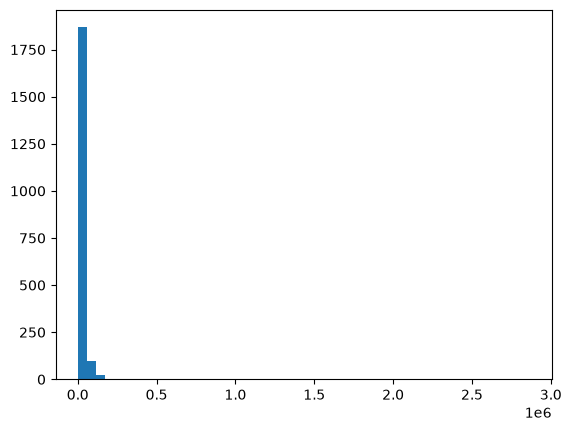

In [29]:
plt.hist(lengths, bins=50)

plt.savefig(
    "../figures/Judgement_lengths.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
length_data = []

for file in files[:2000]:
    with open(file, encoding="utf-8") as f:
        text = f.read()

    length_data.append((file.name, len(text)))

length_data = sorted(length_data, key=lambda x: x[1], reverse=True)

length_data[:10]

[('S_1973_1_1_1002_EN.md', 2862997),
 ('1951_1_747_1125_EN.md', 807789),
 ('1950_1_88_334_EN.md', 545112),
 ('1955_2_603_841_EN.md', 531198),
 ('1967_2_762_948_EN.md', 527904),
 ('1964_6_461_593_EN.md', 292583),
 ('1952_1_889_1019_EN.md', 286893),
 ('1950_1_621_741_EN.md', 263339),
 ('1964_7_267_360_EN.md', 249646),
 ('1957_1_488_574_EN.md', 194002)]

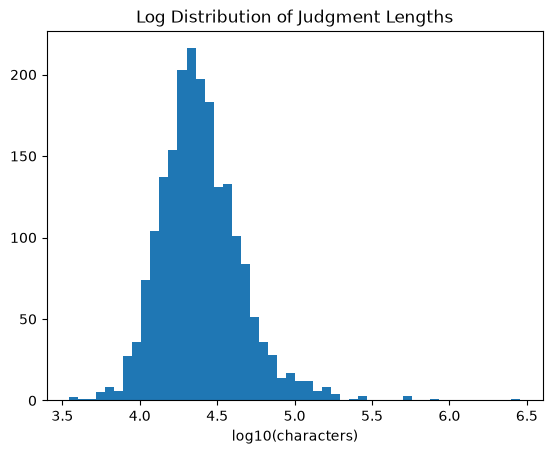

In [28]:
import numpy as np

plt.hist(np.log10(lengths), bins=50)
plt.title("Log Distribution of Judgment Lengths")
plt.xlabel("log10(characters)")

plt.savefig(
    "../figures/log_distribution_judgementlens.png",
    bbox_inches="tight"
)

plt.show()

## Some files represent compiled law report volumes rather than individual cases.


In [23]:
sum(l > 500000 for l in lengths)

5

In [24]:
monster = [x for x in files if "S_1973_1_1_1002_EN" in x.name][0]

with open(monster, encoding="utf-8") as f:
    text = f.read()

print(text[:5000])

HIS HOLINESS KESAVANANDA BHARAT!

SRIPADAGALA VAR U

STATE OF KERALA April 24, 1973

(S. M. SIKRI, C. J., J. M. SHELAT, K. S. HEGDE, A. N.

GROVER, A. N. RAY, P. JAGANMOHAN REDDY, D. G.

PALEK.AR, H. R. KHANNA, IC K. MATHEW, M. H. BEG,

S. N. DWIVEDI, A.

K. MUKHERJEA

AND Y. V.

CHANDRACHUD, JJ.)

Constitution of India, 1950-Artick 368 before Constitution (Twenty Fourth) Amendment Act, 197!-Nature and scope of the amending power.

Article 13(2)-'Law' in 13(2) if includes amendment of the Constitution- Distinction between legislative power and constituent power.

Article 368-"Amendment" meaning of-"Amcndmcnt" if includes the power to abrogate the Constitution-If includes the power to alter the basic structure or frame-work of the Constitution,

Fundamental Rights-If amendment can take away or abridge the rights guaranteed in Part III.

Fundamental Righu--If inalienable natur31 rights so as to operate as restriction on the amending power.

Implied and inherent limitations-Power of amend

Judgment lengths are heavily right-skewed. The median judgment length is approximately 23k characters, while a small number of landmark constitutional cases exceed 500k characters. The largest identified document (~2.86M characters) corresponds to the Kesavananda Bharati case and appears to be a legitimate legal document rather than a data-quality issue.

# CONCLUSION

Dataset contains 33,016 judgments

Coverage spans 1950–2026

Case volume increases significantly after the 1990s

Large spikes exist around 1996 and 2007–2009

Median judgment length ≈ 23k characters

Most judgments fall between 18k–38k characters

Extreme outliers exist but are rare

Largest document (~2.86M chars) is a legitimate constitutional case (Kesavananda Bharati)

Filename structure appears mostly consistent with a small subset of S_ prefixed files

Dataset quality appears suitable for metadata extraction and retrieval systems